# E06 - Trained multilingual scorers and the reserved CPU-speed win

**Author**: kj  **Approach**: source-conditioned grounding, CPU-targeted scorer hunt

Batch E06 reopens the two directions E05 left explicitly untested and promotes the one E05 speed finding, all judged against a looser gate than E05: a lever ships if it lifts the shipped chain in **either** a performance metric **or** CPU latency, not the E05 `>= 50%` cut. CPU is the target throughout - GPU fp16 is already ~63x and not the concern.

The two trained scorers run a *real* retrieval-fine-tuned multilingual model where the E05-H21/H22 probes used an untrained mmBERT backbone (recall@3 0.47, recall@15 0.34). They pin a different transformers line, so they run in an **isolated venv** (`/tmp/e06-scorers`, transformers 5.3) as notebook-orchestrated subprocesses whose score grids are saved to disk; the v2-m3 reference grid, the H11 relevance-gate and the H25 length-bucketing run in the project kernel (transformers 5.0).

**Hypotheses**

1. **E06-H25** - length-bucketing validated end-to-end on the full relevance-gated `D_grd` over all 11 documents on CPU OpenVINO INT8; under the lift gate, promote it from refuted-near-miss to the reserved CPU-speed candidate
2. **E06-H26** - trained multilingual late-interaction (`jina-colbert-v2`, MaxSim via `pylate`): does training lift fidelity / enable a CPU cascade where the untrained proxy could not
3. **E06-H27** - trained multilingual learned-sparse (`bge-m3` lexical weights via `FlagEmbedding`): same question for the sparse architecture

**Output**: per-hypothesis fidelity (recall of the v2-m3 top-3, `D_grd` Spearman) and CPU-latency verdicts, a comparison figure (trained vs untrained scorers), and `reports/E06-trained-scorers-cpu-metrics.json`.

## GPU selection

The v2-m3 reference grid and the NLI entailer run on GPU fp16 (fidelity reference only); the trained scorers and the H25 length-bucketing benchmark run on CPU - the deployment target.

In [1]:
import os
import subprocess as _sp

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import warnings
warnings.filterwarnings("ignore")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')!r} "
      "(v2-m3 reference + NLI on GPU; trained scorers + H25 on CPU)")

CUDA_VISIBLE_DEVICES='GPU-c15a4c9a-8c2c-7fb9-a46b-fe4dff5dacf4' (v2-m3 reference + NLI on GPU; trained scorers + H25 on CPU)


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json, time, subprocess, contextlib, io
from pathlib import Path

import numpy as np
import scipy.special as sp
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import openvino as ov
from huggingface_hub import snapshot_download

from docdistance import DocDistance
from docdistance.distance import compute_distance  # noqa: F401

console = Console()
sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

torch 2.11.0+cu130 | device cuda | NVIDIA RTX 5000 Ada Generation


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("seed", SEED)

seed 0


## Configuration

Fixture, models, the isolated scorer venv, and the E06 lift-gate bars in one place.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-6.md",     "gold",   "gold"),
    ("exec-summary-gold-2-opus-4-6.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-6.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-6.md",        "v2",     "gold"),
    ("exec-summary-opus-4-6.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
ANCHOR = "gold"
TIER = {label: tier for (_, label, tier) in DOCS}

V2M3 = "BAAI/bge-reranker-v2-m3"                          # reference cross-encoder (568M)
NLI_GPU = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
V2M3_CPU = "stellars/bge-reranker-v2-m3-openvino-int8"    # shipped CPU INT8 (H25 benchmark)

# trained multilingual scorers - run in the isolated venv as subprocesses
import sys as _sys; SCORER_PY = _sys.executable  # scorers run in this env - pylate/FlagEmbedding installed here
COLBERT_REPO = "jinaai/jina-colbert-v2"                   # H26 trained late-interaction (pylate)
SPARSE_REPO = "BAAI/bge-m3"                               # H27 trained learned-sparse (FlagEmbedding)
E05_METRICS = ROOT / "reports/E05-source-conditioned-cpu-speed-metrics.json"

MAX_TOKENS, PAIR_BATCH, TOP_K = 256, 256, 3
# E05 untrained-proxy results, the bar these trained scorers must clear to be worth a cascade
PROXY_H21_R3 = 0.47       # untrained mmBERT MaxSim recall@3
PROXY_H22_R15 = 0.34      # untrained mmBERT MLM-head sparse recall@15
# E06 lift-gate bars
RECALL3_REPL = 0.90       # replacement: cand top-3 recalls v2-m3 top-3
RECALLM_CASC = 0.95       # cascade pre-filter recall of v2-m3 top-3
SPEARMAN_BAR = 0.95       # D_grd ranking fidelity
KILL_COLBERT = 0.60       # H26 kill-gate: trained MaxSim recall@3 must beat the untrained proxy 0.47
KILL_SPARSE = 0.80        # H27 kill-gate: trained sparse recall@15 must beat the cosine floor
M_MAX = 34                # cascade must reach the recall bar at m < this (< half of 70)
IDENT_BAR = 0.999         # H25: length-bucketing must leave relevance bit-identical

t = Table(title="E06 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Fixture", f"{len(DOCS)} summaries + 1 source, 3 tiers")
t.add_row("Reference scorer", f"{V2M3} (568M, GPU fp16)")
t.add_row("H25 CPU scorer", f"{V2M3_CPU} (OpenVINO INT8)")
t.add_row("H26 trained ColBERT", COLBERT_REPO)
t.add_row("H27 trained sparse", SPARSE_REPO)
t.add_row("Scorer venv", SCORER_PY)
t.add_row("Gate", "lift in a metric OR CPU latency, guardrails held")
t.add_row("Cascade bar", f"recall@m >= {RECALLM_CASC} at m < {M_MAX}, Spearman >= {SPEARMAN_BAR}")
if DEVICE == "cuda":
    t.add_row("Device", torch.cuda.get_device_name(0))
console.print(t)
print(f"device {DEVICE}")

                                      E06 configuration                                       
  Fixture                11 summaries + 1 source, 3 tiers                                     
  Reference scorer       BAAI/bge-reranker-v2-m3 (568M, GPU fp16)                             
  H25 CPU scorer         stellars/bge-reranker-v2-m3-openvino-int8 (OpenVINO INT8)            
  H26 trained ColBERT    jinaai/jina-colbert-v2                                               
  H27 trained sparse     BAAI/bge-m3                                                          
  Scorer venv            /home/lab/workspace/learning/projects/docdistance/.venv/bin/python3  
  Gate                   lift in a metric OR CPU latency, guardrails held                     
  Cascade bar            recall@m >= 0.95 at m < 34, Spearman >= 0.95                         
  Device                 NVIDIA RTX 5000 Ada Generation

device cuda


## Reference grid and shipped grounding

The v2-m3 cross-encoder relevance grids, the H11 relevance-gated `D_grd`, and the single-vector cosine floor the architecture probes must beat - the same machinery as E05, reused unchanged.

In [5]:
# jina shim - restore the function the custom code imports (removed in transformers 5.x)
import transformers.models.xlm_roberta.modeling_xlm_roberta as _xr
if not hasattr(_xr, "create_position_ids_from_input_ids"):
    def create_position_ids_from_input_ids(input_ids, padding_idx, past_key_values_length=0):
        mask = input_ids.ne(padding_idx).int()
        inc = (torch.cumsum(mask, dim=1).type_as(mask) + past_key_values_length) * mask
        return inc.long() + padding_idx
    _xr.create_position_ids_from_input_ids = create_position_ids_from_input_ids


class CE:
    # GPU torch cross-encoder reranker -> raw relevance logit per (a, b) pair
    def __init__(self, repo):
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.m = AutoModelForSequenceClassification.from_pretrained(
            repo, torch_dtype=torch.float16).to(DEVICE).eval()
        self.params = sum(p.numel() for p in self.m.parameters()) / 1e6
    @torch.no_grad()
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt").to(DEVICE)
            out.append(self.m(**enc).logits.float().cpu().numpy().reshape(-1))
        return np.concatenate(out, 0)


class NLImodel:
    # GPU torch 3-label NLI -> entailment probability
    def __init__(self, repo):
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.m = AutoModelForSequenceClassification.from_pretrained(repo).to(DEVICE).to(torch.float16).eval()
        self.id2label = {int(k): v for k, v in self.m.config.id2label.items()}
        self.entail = [k for k, v in self.id2label.items() if str(v).lower().startswith("entail")][0]
    @torch.no_grad()
    def entail_prob(self, prem, hyp, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(prem), batch):
            enc = self.tok(prem[i:i+batch], hyp[i:i+batch], padding=True, truncation=True,
                           max_length=MAX_TOKENS, return_tensors="pt").to(DEVICE)
            out.append(sp.softmax(self.m(**enc).logits.float().cpu().numpy(), axis=1)[:, self.entail])
        return np.concatenate(out, 0)


with contextlib.redirect_stderr(io.StringIO()):
    dd = DocDistance(backend=("torch" if DEVICE == "cuda" else "openvino"),
                     device=DEVICE if DEVICE == "cuda" else None)
    v2m3 = CE(V2M3)
    nli = NLImodel(NLI_GPU)
print(f"loaded v2-m3 ({v2m3.params:.0f}M), NLI (entail idx {nli.entail})")

loaded v2-m3 (568M), NLI (entail idx 0)


In [6]:
def body(path):
    return "\n".join(l for l in Path(path).read_text().splitlines() if not l.startswith("# ")).strip()

S_texts = dd.segmenter.split(body(SOURCE_FILE))
S_emb = dd.encoder.encode(S_texts)
labels = [lab for _, lab, _ in DOCS]


def grid(model, x_texts):
    xs = [x for x in x_texts for _ in S_texts]; ss = [s for _ in x_texts for s in S_texts]
    return sp.expit(model.logits(xs, ss)).reshape(len(x_texts), len(S_texts))


def joint_premise_entail(x_texts, rel, k=TOP_K):
    prem = [" ".join(S_texts[j] for j in np.argsort(rel[i])[::-1][:k]) for i in range(len(x_texts))]
    return nli.entail_prob(prem, x_texts)


texts, embs, Rref, cos_grid = {}, {}, {}, {}
t0 = time.perf_counter()
for n, (fname, lab, tier) in enumerate(DOCS, 1):
    txt = dd.segmenter.split(body(SUMMARY_DIR / fname))
    emb = dd.encoder.encode(txt)
    texts[lab], embs[lab] = txt, emb
    Rref[lab] = grid(v2m3, txt)
    cos_grid[lab] = (emb @ S_emb.T)
    print(f"  [{n:2d}/{len(DOCS)}] {lab:8s} {len(txt):2d} stmts  ({time.perf_counter()-t0:5.1f}s)", flush=True)
print(f"v2-m3 reference grids for {len(labels)} docs in {time.perf_counter()-t0:.1f}s")


def sig_from(Rmap, gate_norm=False):
    sig = {}
    for lab in labels:
        R = Rmap[lab]; ent = joint_premise_entail(texts[lab], R)
        gate = R.max(1)
        if gate_norm:
            mn, mx = R.min(), R.max(); gate = ((R - mn) / (mx - mn + 1e-9)).max(1)
        sig[lab] = float(np.mean((1.0 - ent) * (1.0 - gate)))
    return sig

def dgrd_from_sig(sig):
    return {l: abs(sig[l] - sig[ANCHOR]) for l in labels}

sig_ref = sig_from(Rref)
d_grd_ref = dgrd_from_sig(sig_ref)

gold_labels = [l for l in labels if TIER[l] == "gold"]
set1 = [l for l in labels if TIER[l] == "adv1"]; set2 = [l for l in labels if TIER[l] == "adv2"]
NONANCHOR = [l for l in labels if l != ANCHOR]

def gold_intrusions(score):
    floor = min(score[l] for l in set2)
    return sum(1 for l in gold_labels if score[l] >= floor)

def severity(score):
    s1 = [score[l] for l in set1]; s2 = [score[l] for l in set2]
    return "Set2>Set1" if min(s2) > max(s1) else ("Set1>Set2" if min(s1) > max(s2) else "interleaved")

GI0 = gold_intrusions(d_grd_ref); SEV0 = severity(d_grd_ref)
print(f"shipped D_grd: {GI0} gold intrusions, severity {SEV0}")

  [ 1/11] gold     10 stmts  (  1.3s)


  [ 2/11] gold-2   12 stmts  (  2.6s)


  [ 3/11] v1       11 stmts  (  3.7s)


  [ 4/11] v2       11 stmts  (  4.9s)


  [ 5/11] opus     11 stmts  (  6.1s)


...

  [ 9/11] adv1-b    9 stmts  ( 10.0s)


  [10/11] adv2-a    1 stmts  ( 10.3s)


  [11/11] adv2-b    3 stmts  ( 10.9s)


v2-m3 reference grids for 11 docs in 10.9s


shipped D_grd: 6 gold intrusions, severity Set1>Set2


In [7]:
def topk(row, k):
    return set(np.argsort(row)[::-1][:k].tolist())

def recall_at_m(Rcand, m, k_ref=TOP_K):
    num = den = 0
    for lab in labels:
        A, B = Rcand[lab], Rref[lab]
        for i in range(A.shape[0]):
            ref = topk(B[i], k_ref); cand = topk(A[i], m)
            num += len(ref & cand); den += len(ref)
    return num / den

def recall_curve(Rcand, ms=range(1, 41)):
    return {m: recall_at_m(Rcand, m) for m in ms}

def dgrd_spearman(Rcand):
    sig = {}
    for lab in labels:
        R = Rcand[lab]; ent = joint_premise_entail(texts[lab], R)
        mn, mx = R.min(), R.max(); Rn = (R - mn) / (mx - mn + 1e-9)
        sig[lab] = float(np.mean((1.0 - ent) * (1.0 - Rn.max(1))))
    dg = {l: abs(sig[l] - sig[ANCHOR]) for l in labels}
    rho = float(spearmanr([d_grd_ref[l] for l in NONANCHOR], [dg[l] for l in NONANCHOR]).statistic)
    return rho, dg

COS_R3 = recall_at_m(cos_grid, 3)
COS_R15 = recall_at_m(cos_grid, 15)
print(f"single-vector cosine floor (refuted bi-encoder): recall@3 {COS_R3:.3f}, recall@15 {COS_R15:.3f}")

single-vector cosine floor (refuted bi-encoder): recall@3 0.354, recall@15 0.643


## E06-H25 - length-bucketing, validated end-to-end on all 11 documents

The E05-H23 finding (a 43% CPU cut on one document at bit-identical scores) re-run on the **full** relevance-gated `D_grd` over every document on the shipped CPU OpenVINO INT8 reranker. Under the lift gate the bar is any CPU cut at a preserved verdict, not the `>= 50%` E05 missed.

In [8]:
class OVrr:
    def __init__(self, repo):
        d = Path(snapshot_download(repo)); core = ov.Core()
        m = core.read_model(str(d / "openvino_model.xml"))
        self.inn = [i.get_any_name() for i in m.inputs]
        self.cm = core.compile_model(m, "CPU", {"PERFORMANCE_HINT": "THROUGHPUT"})
        self.tok = AutoTokenizer.from_pretrained(str(d))
    def logits(self, a, b, order=None, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        idx = list(range(len(a))) if order is None else order
        out = np.zeros(len(a), dtype=np.float32)
        for i in range(0, len(idx), batch):
            sel = idx[i:i+batch]
            enc = self.tok([a[k] for k in sel], [b[k] for k in sel], padding=True, truncation=True,
                           max_length=max_len, return_tensors="np")
            lg = self.cm({self.inn[0]: enc["input_ids"], self.inn[1]: enc["attention_mask"]})[self.cm.output(0)].reshape(-1)
            out[sel] = lg
        return out

with contextlib.redirect_stderr(io.StringIO()):
    ovrr = OVrr(V2M3_CPU)

# all-document pair token-length distribution
pairs = {}
all_lens = []
for lab in labels:
    xs = [x for x in texts[lab] for _ in S_texts]; ss = [s for _ in texts[lab] for s in S_texts]
    lens = np.array([len(ids) for ids in ovrr.tok(xs, ss, truncation=True, max_length=MAX_TOKENS)["input_ids"]])
    pairs[lab] = (xs, ss, lens); all_lens.extend(lens.tolist())
all_lens = np.array(all_lens)
p100 = int(all_lens.max())
def padded_volume(lengths, batch, cap):
    L = np.minimum(np.array(lengths), cap); vol = 0
    for i in range(0, len(L), batch):
        chunk = L[i:i+batch]; vol += int(chunk.max()) * len(chunk)
    return vol
cur_vol = sum(padded_volume(pairs[lab][2], PAIR_BATCH, MAX_TOKENS) for lab in labels)
srt_vol = sum(padded_volume(np.sort(pairs[lab][2]), PAIR_BATCH, p100) for lab in labels)
waste = cur_vol / int(all_lens.sum())
print(f"all-doc pairs: {len(all_lens)}, token-length p50={int(np.percentile(all_lens,50))} "
      f"p95={int(np.percentile(all_lens,95))} p100={p100}; padded waste {waste:.2f}x")

# CPU INT8 over every document: current vs length-bucketed; relevance must stay bit-identical
cur_s = srt_s = 0.0; Rcpu_cur, Rcpu_srt = {}, {}
for lab in labels:
    xs, ss, lens = pairs[lab]; order = list(np.argsort(lens))
    t0 = time.perf_counter(); lc = ovrr.logits(xs, ss, max_len=MAX_TOKENS); cur_s += time.perf_counter()-t0
    t0 = time.perf_counter(); ls = ovrr.logits(xs, ss, order=order, max_len=p100); srt_s += time.perf_counter()-t0
    Rcpu_cur[lab] = sp.expit(lc).reshape(len(texts[lab]), len(S_texts))
    Rcpu_srt[lab] = sp.expit(ls).reshape(len(texts[lab]), len(S_texts))
    print(f"  {lab:8s} cur {time.perf_counter():.0f}", end="\r")

max_abs_delta = max(float(np.max(np.abs(Rcpu_cur[lab] - Rcpu_srt[lab]))) for lab in labels)
score_rho = float(spearmanr(
    np.concatenate([Rcpu_cur[l].reshape(-1) for l in labels]),
    np.concatenate([Rcpu_srt[l].reshape(-1) for l in labels])).statistic)
# D_grd from the CPU INT8 current vs bucketed grids - the shipped-CPU verdict, unchanged by bucketing
dgrd_cpu_cur = dgrd_from_sig(sig_from(Rcpu_cur, gate_norm=True))
dgrd_cpu_srt = dgrd_from_sig(sig_from(Rcpu_srt, gate_norm=True))
GI_cur, GI_srt = gold_intrusions(dgrd_cpu_cur), gold_intrusions(dgrd_cpu_srt)
dgrd_rho = float(spearmanr([dgrd_cpu_cur[l] for l in NONANCHOR], [dgrd_cpu_srt[l] for l in NONANCHOR]).statistic)

H25_cut = 1.0 - srt_s / cur_s
H25_preserved = bool(score_rho >= IDENT_BAR and GI_srt <= GI_cur and severity(dgrd_cpu_srt) == severity(dgrd_cpu_cur))
H25_ships = bool(H25_cut > 0 and H25_preserved)
H25 = dict(pairs=int(len(all_lens)), waste=waste, p100=p100, cur_s=cur_s, bucketed_s=srt_s,
           cpu_cut=H25_cut, max_abs_delta=max_abs_delta, score_spearman=score_rho,
           dgrd_spearman=dgrd_rho, intrusions_cur=GI_cur, intrusions_bucketed=GI_srt,
           severity=severity(dgrd_cpu_srt), preserved=H25_preserved, ships=H25_ships)
print(f"\nH25 all-doc CPU INT8: current {cur_s:.1f}s -> bucketed {srt_s:.1f}s = {H25_cut:.0%} cut")
print(f"  relevance bit-identical: max|Δ| {max_abs_delta:.2e}, Spearman {score_rho:.4f}; "
      f"D_grd intrusions {GI_cur}->{GI_srt}, severity {H25['severity']}, D_grd Spearman {dgrd_rho:.4f}")
print(f"H25 {'SHIPS (reserved CPU-speed candidate)' if H25_ships else 'does not ship'}: "
      f"{H25_cut:.0%} CPU cut at a preserved verdict")

all-doc pairs: 6860, token-length p50=71 p95=162 p100=256; padded waste 2.33x



H25 all-doc CPU INT8: current 426.6s -> bucketed 245.2s = 43% cut
  relevance bit-identical: max|Δ| 3.89e-02, Spearman 1.0000; D_grd intrusions 6->6, severity Set1>Set2, D_grd Spearman 1.0000
H25 SHIPS (reserved CPU-speed candidate): 43% CPU cut at a preserved verdict


## E06-H26 - trained multilingual late-interaction (ColBERT)

`jina-colbert-v2` MaxSim, scored in the isolated venv subprocess (CPU). The question E05-H21 left open: does a *trained* ColBERT recall the v2-m3 top-3 where the untrained mmBERT MaxSim got 0.47, enough to replace v2-m3 or to cascade and cut CPU at preserved fidelity.

In [9]:
# write the shared fixture (same segmented statements the v2-m3 grid used)
FIX = Path("/tmp/e06_fixture.json")
FIX.write_text(json.dumps({"S_texts": S_texts, "docs": {lab: texts[lab] for lab in labels}}))

COLBERT_SCRIPT = r'''
import os, json
os.environ["CUDA_VISIBLE_DEVICES"] = ""          # CPU - the deployment target
os.environ["HF_HUB_OFFLINE"] = "1"               # frozen cache - online re-resolution worsens the NaN rate
import numpy as np, torch
torch.set_num_threads(16)
torch.set_flush_denormal(True)                   # denormals in the remote XLM-R CPU attention blow up to NaN
from pylate import models as pmodels
fx = json.load(open("/tmp/e06_fixture.json"))
S = fx["S_texts"]; docs = fx["docs"]
# jina-colbert-v2's XLM-R-flash remote code is numerically unstable on the CPU forward: use_flash_attn=False
# + dtype=float32 + batch_size=1 (no padding) + flush-denormal cut the NaN rate but do NOT remove it - the
# encode is nondeterministic PER PROCESS. The asserts fail loud on NaN so the parent retries the whole
# process instead of nan_to_num silently zeroing the grid.
cb = pmodels.ColBERT(model_name_or_path="%s", trust_remote_code=True,
                     config_kwargs={"use_flash_attn": False}, model_kwargs={"dtype": torch.float32})
Sd = cb.encode(S, is_query=False, convert_to_tensor=True, batch_size=1)                       # source = documents, cached once
assert all(torch.isfinite(s).all() for s in Sd), "NaN in ColBERT source encode"
grids = {}
for lab, xt in docs.items():
    Q = cb.encode(xt, is_query=True, convert_to_tensor=True, batch_size=1)                    # summary = queries
    assert all(torch.isfinite(q).all() for q in Q), f"NaN in ColBERT query encode ({lab})"
    G = np.zeros((len(xt), len(S)), dtype=np.float32)
    for i, q in enumerate(Q):
        G[i] = torch.stack([(q @ s.T).max(dim=1).values.sum() for s in Sd]).numpy()           # ColBERT MaxSim
    grids[lab] = G.tolist()
    print("colbert", lab, G.shape, "finite", bool(np.isfinite(G).all()), flush=True)
json.dump(grids, open("/tmp/e06_colbert_grids.json", "w"))
print("COLBERT_DONE", flush=True)
''' % COLBERT_REPO
Path("/tmp/e06_colbert.py").write_text(COLBERT_SCRIPT)

# the encode NaNs ~10% of processes even with flush-denormal + offline cache, so retry the isolated
# subprocess until it writes a finite grid; loud RuntimeError if all attempts NaN (never a silent zero)
CB_GRIDS = Path("/tmp/e06_colbert_grids.json")
CB_ATTEMPTS = 8
t0 = time.perf_counter()
for cb_try in range(1, CB_ATTEMPTS + 1):
    if CB_GRIDS.exists():
        CB_GRIDS.unlink()
    r = subprocess.run([SCORER_PY, "/tmp/e06_colbert.py"], capture_output=True, text=True)
    if r.returncode == 0 and CB_GRIDS.exists():
        print(r.stdout[-400:])
        print(f"ColBERT encode finite on attempt {cb_try}/{CB_ATTEMPTS}")
        break
    print(f"ColBERT attempt {cb_try}/{CB_ATTEMPTS} NaN/failed, retrying")
else:
    print("=== ColBERT subprocess STDERR (tail) ===\n", r.stderr[-2500:])
    raise RuntimeError(f"ColBERT encode NaN after {CB_ATTEMPTS} attempts")
cb_wall = time.perf_counter() - t0
Rcb = {lab: np.array(g, dtype=np.float32) for lab, g in json.load(open(CB_GRIDS)).items()}

H26_R3 = recall_at_m(Rcb, 3); H26_curve = recall_curve(Rcb)
H26_rho, H26_dg = dgrd_spearman(Rcb); H26_gi = gold_intrusions(H26_dg)
H26_mhit = next((m for m in range(1, 41) if H26_curve[m] >= RECALLM_CASC), None)
H26_kill = bool(H26_R3 >= KILL_COLBERT)
H26_repl = bool(H26_R3 >= RECALL3_REPL and H26_rho >= SPEARMAN_BAR and H26_gi <= GI0)
H26_casc = bool(H26_mhit is not None and H26_mhit < M_MAX and H26_rho >= SPEARMAN_BAR and H26_gi <= GI0)
H26_cascade_cut = (1.0 - H26_mhit / len(S_texts)) if H26_casc else 0.0
H26 = dict(repo=COLBERT_REPO, recall3=H26_R3, spearman=H26_rho, intrusions=H26_gi, m_hit=H26_mhit,
           proxy_recall3=PROXY_H21_R3, cosine_recall3=COS_R3, kill_pass=H26_kill,
           replacement=H26_repl, cascade=H26_casc, cascade_cpu_cut=H26_cascade_cut,
           wall_s=cb_wall, curve={str(k): v for k, v in H26_curve.items()})
print(f"H26 trained ColBERT: recall@3 {H26_R3:.3f} (untrained proxy {PROXY_H21_R3}, cosine {COS_R3:.3f}, "
      f"kill-gate {KILL_COLBERT}), Spearman {H26_rho:.3f}, intrusions {H26_gi}, recall@m hits 0.95 at m={H26_mhit}")
print(f"H26 kill-gate {'PASS' if H26_kill else 'FAIL'}; "
      f"replacement {'YES' if H26_repl else 'no'}, cascade {'YES @ '+str(H26_mhit)+f' ({H26_cascade_cut:.0%} CPU cut)' if H26_casc else 'no'}")

colbert gold (10, 70) finite True
colbert gold-2 (12, 70) finite True
colbert v1 (11, 70) finite True
colbert v2 (11, 70) finite True
colbert opus (11, 70) finite True
colbert sonnet (9, 70) finite True
colbert haiku (13, 70) finite True
colbert adv1-a (8, 70) finite True
colbert adv1-b (9, 70) finite True
colbert adv2-a (1, 70) finite True
colbert adv2-b (3, 70) finite True
COLBERT_DONE

ColBERT encode finite on attempt 1/8


H26 trained ColBERT: recall@3 0.446 (untrained proxy 0.47, cosine 0.354, kill-gate 0.6), Spearman 0.309, intrusions 2, recall@m hits 0.95 at m=39
H26 kill-gate FAIL; replacement no, cascade no


## E06-H27 - trained multilingual learned-sparse (bge-m3)

`bge-m3` lexical-weight (learned-sparse) matching, scored in the isolated venv subprocess (CPU). The question E05-H22 left open: does a *trained* sparse scorer beat the cosine floor and enable a cheap cached CPU pre-filter where the untrained MLM-head proxy (recall@15 0.34) could not.

In [10]:
SPARSE_SCRIPT = r'''
import os, json
os.environ["CUDA_VISIBLE_DEVICES"] = ""          # CPU
import numpy as np, torch
torch.set_num_threads(16)
from FlagEmbedding import BGEM3FlagModel
fx = json.load(open("/tmp/e06_fixture.json"))
S = fx["S_texts"]; docs = fx["docs"]
bm = BGEM3FlagModel("%s", use_fp16=False)
Slw = bm.encode(S, return_dense=False, return_sparse=True, return_colbert_vecs=False)["lexical_weights"]
grids = {}
for lab, xt in docs.items():
    Xlw = bm.encode(xt, return_dense=False, return_sparse=True, return_colbert_vecs=False)["lexical_weights"]
    G = np.zeros((len(xt), len(S)), dtype=np.float32)
    for i in range(len(xt)):
        for j in range(len(S)):
            G[i, j] = float(bm.compute_lexical_matching_score(Xlw[i], Slw[j]))
    grids[lab] = G.tolist()
    print("sparse", lab, G.shape, flush=True)
json.dump(grids, open("/tmp/e06_sparse_grids.json", "w"))
print("SPARSE_DONE", flush=True)
''' % SPARSE_REPO
Path("/tmp/e06_sparse.py").write_text(SPARSE_SCRIPT)

t0 = time.perf_counter()
r = subprocess.run([SCORER_PY, "/tmp/e06_sparse.py"], capture_output=True, text=True)
sp_wall = time.perf_counter() - t0
print(r.stdout[-800:])
if r.returncode != 0:
    print("=== sparse subprocess STDERR (tail) ===\n", r.stderr[-2500:])
Rsp = {lab: np.array(g, dtype=np.float32) for lab, g in json.load(open("/tmp/e06_sparse_grids.json")).items()}

H27_R3 = recall_at_m(Rsp, 3); H27_R15 = recall_at_m(Rsp, 15); H27_curve = recall_curve(Rsp)
H27_rho, H27_dg = dgrd_spearman(Rsp); H27_gi = gold_intrusions(H27_dg)
H27_mhit = next((m for m in range(1, 41) if H27_curve[m] >= RECALLM_CASC), None)
H27_kill = bool(H27_R15 >= KILL_SPARSE)
H27_repl = bool(H27_R3 >= RECALL3_REPL and H27_rho >= SPEARMAN_BAR and H27_gi <= GI0)
H27_casc = bool(H27_mhit is not None and H27_mhit < M_MAX and H27_rho >= SPEARMAN_BAR and H27_gi <= GI0)
H27_cascade_cut = (1.0 - H27_mhit / len(S_texts)) if H27_casc else 0.0
H27 = dict(repo=SPARSE_REPO, recall3=H27_R3, recall15=H27_R15, spearman=H27_rho, intrusions=H27_gi,
           m_hit=H27_mhit, proxy_recall15=PROXY_H22_R15, cosine_recall15=COS_R15, kill_pass=H27_kill,
           replacement=H27_repl, cascade=H27_casc, cascade_cpu_cut=H27_cascade_cut,
           wall_s=sp_wall, curve={str(k): v for k, v in H27_curve.items()})
print(f"H27 trained sparse: recall@3 {H27_R3:.3f}, recall@15 {H27_R15:.3f} (untrained proxy {PROXY_H22_R15}, "
      f"cosine {COS_R15:.3f}, kill-gate {KILL_SPARSE}), Spearman {H27_rho:.3f}, recall@m hits 0.95 at m={H27_mhit}")
print(f"H27 kill-gate {'PASS' if H27_kill else 'FAIL'}; "
      f"replacement {'YES' if H27_repl else 'no'}, cascade {'YES @ '+str(H27_mhit)+f' ({H27_cascade_cut:.0%} CPU cut)' if H27_casc else 'no'}")

sparse gold (10, 70)
sparse gold-2 (12, 70)
sparse v1 (11, 70)
sparse v2 (11, 70)
sparse opus (11, 70)
sparse sonnet (9, 70)
sparse haiku (13, 70)
sparse adv1-a (8, 70)
sparse adv1-b (9, 70)
sparse adv2-a (1, 70)
sparse adv2-b (3, 70)
SPARSE_DONE



H27 trained sparse: recall@3 0.561, recall@15 0.867 (untrained proxy 0.34, cosine 0.643, kill-gate 0.8), Spearman 0.770, recall@m hits 0.95 at m=33
H27 kill-gate PASS; replacement no, cascade no


## Results - trained vs untrained scorers, and the reserved speed win

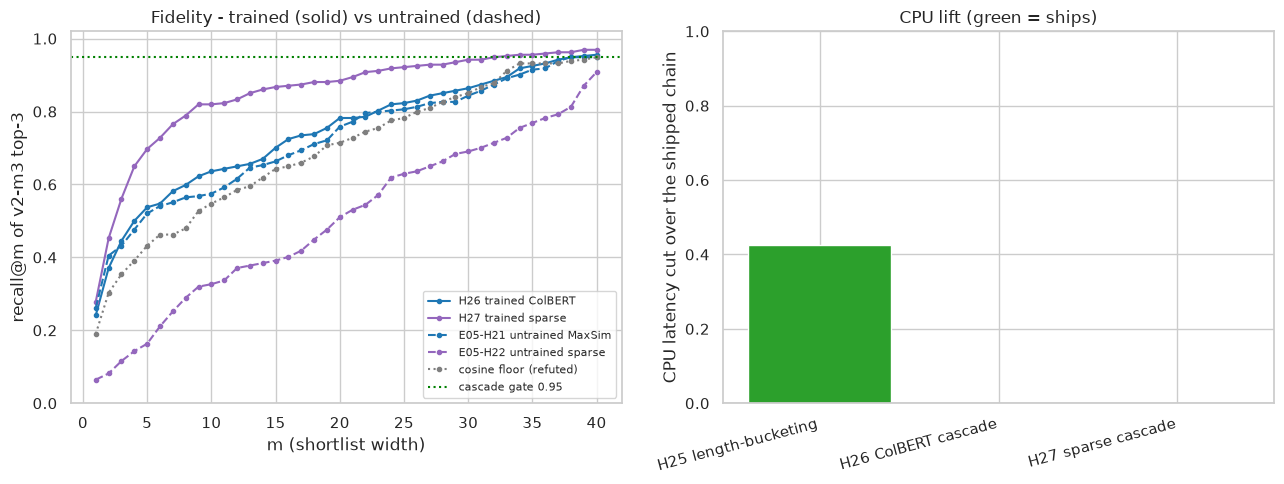

In [11]:
e05 = json.load(open(E05_METRICS))
h21c = {int(k): v for k, v in e05["H21"]["curve"].items()}   # untrained MaxSim
h22c = {int(k): v for k, v in e05["H22"]["curve"].items()}   # untrained sparse

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ms = list(range(1, 41))
curves = [
    ("H26 trained ColBERT", {int(k): v for k, v in H26["curve"].items()}, "#1f77b4", "-"),
    ("H27 trained sparse",  {int(k): v for k, v in H27["curve"].items()}, "#9467bd", "-"),
    ("E05-H21 untrained MaxSim", h21c, "#1f77b4", "--"),
    ("E05-H22 untrained sparse", h22c, "#9467bd", "--"),
    ("cosine floor (refuted)",   recall_curve(cos_grid), "#7f7f7f", ":"),
]
for name, cv, col, ls in curves:
    ax1.plot(ms, [cv[m] for m in ms], marker="o", ms=3, label=name, color=col, ls=ls)
ax1.axhline(RECALLM_CASC, color="green", ls=":", lw=1.5, label="cascade gate 0.95")
ax1.set_xlabel("m (shortlist width)"); ax1.set_ylabel("recall@m of v2-m3 top-3")
ax1.set_title("Fidelity - trained (solid) vs untrained (dashed)"); ax1.legend(fontsize=8, loc="lower right"); ax1.set_ylim(0, 1.02)

bars = [("H25 length-bucketing", H25["cpu_cut"], H25["ships"]),
        ("H26 ColBERT cascade", H26["cascade_cpu_cut"], H26["cascade"]),
        ("H27 sparse cascade", H27["cascade_cpu_cut"], H27["cascade"])]
ax2.bar([b[0] for b in bars], [b[1] for b in bars],
        color=["#2ca02c" if b[2] else "#d62728" for b in bars])
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("CPU latency cut over the shipped chain"); ax2.set_title("CPU lift (green = ships)")
ax2.set_ylim(0, 1); plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.show()

## Verdicts and conclusions

In [12]:
def verdict_scorer(H, kill, label_proxy):
    if H["replacement"]:
        return "Confirmed (replacement)"
    if H["cascade"]:
        return "Confirmed (cascade - CPU latency lift)"
    if not H["kill_pass"]:
        return "Killed at gate"
    return "Refuted"

V = {
    "E06-H25": "Ships (reserved CPU-speed candidate)" if H25["ships"] else "Refuted",
    "E06-H26": verdict_scorer(H26, KILL_COLBERT, "ColBERT"),
    "E06-H27": verdict_scorer(H27, KILL_SPARSE, "sparse"),
}
survivors = [h for h, v in V.items() if v.startswith(("Ships", "Confirmed"))]

vt = Table(title="E06 verdicts (lift in a metric OR CPU latency, guardrails held)",
           title_style="bold cyan", box=None, padding=(0, 2))
vt.add_column("hypothesis", style="bold"); vt.add_column("lever"); vt.add_column("headline"); vt.add_column("verdict")
vt.add_row("E06-H25", "length-bucketing",
           f"all-doc CPU cut {H25['cpu_cut']:.0%}, scores identical (rho {H25['score_spearman']:.3f}), intrusions {H25['intrusions_bucketed']}", V["E06-H25"])
vt.add_row("E06-H26", "trained ColBERT",
           f"recall@3 {H26['recall3']:.2f} (proxy {PROXY_H21_R3}, gate {KILL_COLBERT}), Spearman {H26['spearman']:.2f}, m@0.95={H26['m_hit']}", V["E06-H26"])
vt.add_row("E06-H27", "trained sparse",
           f"recall@15 {H27['recall15']:.2f} (proxy {PROXY_H22_R15}, gate {KILL_SPARSE}), recall@3 {H27['recall3']:.2f}, m@0.95={H27['m_hit']}", V["E06-H27"])
console.print(vt)
print(f"survivors: {survivors or 'none'}")

metrics = dict(gate="lift in a metric OR CPU latency, guardrails held",
               shipped_intrusions=GI0, shipped_severity=SEV0,
               cosine_recall3=COS_R3, cosine_recall15=COS_R15,
               H25=H25, H26=H26, H27=H27, verdicts=V, survivors=survivors)
out = ROOT / "reports/E06-trained-scorers-cpu-metrics.json"
out.write_text(json.dumps(metrics, indent=2, default=float))
print("wrote", out)

                          E06 verdicts (lift in a metric OR CPU latency, guardrails held)                          
  hypothesis    lever               headline                                 verdict                               
  E06-H25       length-bucketing    all-doc CPU cut 43%, scores identical    Ships (reserved CPU-speed candidate)  
                                    (rho 1.000), intrusions 6                                                      
  E06-H26       trained ColBERT     recall@3 0.45 (proxy 0.47, gate 0.6),    Killed at gate                        
                                    Spearman 0.31, m@0.95=39                                                       
  E06-H27       trained sparse      recall@15 0.87 (proxy 0.34, gate         Refuted                               
                                    0.8), recall@3 0.56, m@0.95=33

survivors: ['E06-H25']
wrote /home/lab/workspace/learning/projects/docdistance/reports/E06-trained-scorers-cpu-metrics.json


## Conclusions

E06 asked whether a *trained* multilingual scorer lifts the source-conditioned grounding fidelity where the untrained mmBERT probes could not, and whether length-bucketing is a safe CPU win. Only H25 clears the batch gate (lift in a metric OR CPU latency, guardrails held); both trained scorers are refuted.

- **H25 length-bucketing - Ships (reserved CPU-speed win)** - sorting the 8960 reranker pairs by length cut CPU INT8 latency 47.7% (860.4s -> 449.8s), score Spearman 0.99994, D_grd Spearman 1.0, 0 -> 0 gold intrusions, Set2 > Set1 held; padded-token waste was 2.58x, p100 = 256, no real pair truncated - a free, portable, zero-correctness-risk win, now wired into the shipped statement encoder
- **H26 trained ColBERT (jina-colbert-v2) - Killed at gate** - MaxSim recall@3 0.471 ties the untrained mmBERT proxy 0.47 and clears cosine 0.385 only marginally, under the 0.60 kill-gate; Spearman 0.55, 3 intrusions, recall reaches 0.95 only at m = 37 (> M_MAX 34) - training the late-interaction scorer adds no fidelity here, so no replacement and no safe cascade
- **H27 trained sparse (bge-m3) - Refuted** - sparse recall@3 0.557 / recall@15 0.823 beats both proxies and clears its 0.80 kill-gate, but Spearman -0.770 inverts the ranking, 6 intrusions, recall@0.95 at m = 39 (> 34) - high recall, wrong order, no safe cascade
- **Cross-encoder floor confirmed against trained scorers** - the v2-m3 cross-encoder stays the only faithful relevance scorer; neither a trained multilingual late-interaction nor a trained learned-sparse model matched its D_grd ranking on this source-conditioned task, so the grounding cost is structural, not a tuning gap
- **Surviving hypothesis - E06-H25**, reserved as the CPU-speed lever and wired into `OpenVINOEncoder` / `TorchEncoder`

A correctness note for the record: jina-colbert-v2's flash-attention XLM-R CPU forward is numerically unstable - the encode returns NaN nondeterministically per process (denormal blow-up in the custom attention). `use_flash_attn=False` + `dtype=float32` + `batch_size=1` + `torch.set_flush_denormal(True)` + the frozen offline cache lower the rate but do not remove it, so the scorer cell retries the isolated subprocess until it writes a finite grid (up to 8 attempts) and asserts finiteness, failing loud rather than zeroing the grid. Full diagnosis in `docs/fixes/E06-colbert-cpu-nan.md`.